In [2]:
import os,csv,re
import pandas as pd
import numpy as np
import scanpy as sc
import math
from scipy.sparse import issparse
import random
import warnings
warnings.filterwarnings("ignore")
import matplotlib.colors as clr
import matplotlib.pyplot as plt
from scanpy import read_10x_h5
import pickle
import seaborn as sns

In [3]:
plt.rcParams['pdf.fonttype'] = 42  
%config InlineBackend.figure_format = 'retina'

In [4]:
import PyComplexHeatmap
from PyComplexHeatmap import *

In [5]:
sc.settings.verbosity = 3 
sc.settings.set_figure_params(dpi=200, dpi_save=300,
                              facecolor='white', figsize=(4,4))

In [6]:
import sys
import seaborn as sns

In [7]:
sns.set_style('ticks')

In [8]:
def plot_spatial(anndata, sample, key='sample', **kwargs):
    sc.pl.spatial( anndata[anndata.obs[key]==sample], library_id=sample, **kwargs, use_raw=False)

In [51]:
merged_all_ST_analysed = sc.read_h5ad('./data/ST/merged_all_ST_analysed.h5ad')

In [82]:
meta = merged_all_ST_analysed.obs.copy()

In [85]:
jaccard_df = []
for patho in meta['patho_anno'].cat.categories:
    for niche in meta['spatial_domain'].unique():
        patho_spots = meta.index[meta['patho_anno'] == patho]
        niche_spots = meta.index[meta['spatial_domain'] == niche]
        jaccard = len(np.intersect1d(patho_spots, niche_spots)) / len(np.union1d(patho_spots, niche_spots)) 
        jaccard_df.append([patho, niche, jaccard])
jaccard_df = pd.DataFrame(jaccard_df, columns=['patho_anno', 'spatial_domain', 'jaccard index'])

In [86]:
jaccard_df['spatial_domain'] = [int(i[-1]) for i in jaccard_df['spatial_domain']]  ## transfer domain name to number for ploting

<Figure size 1200x1000 with 0 Axes>

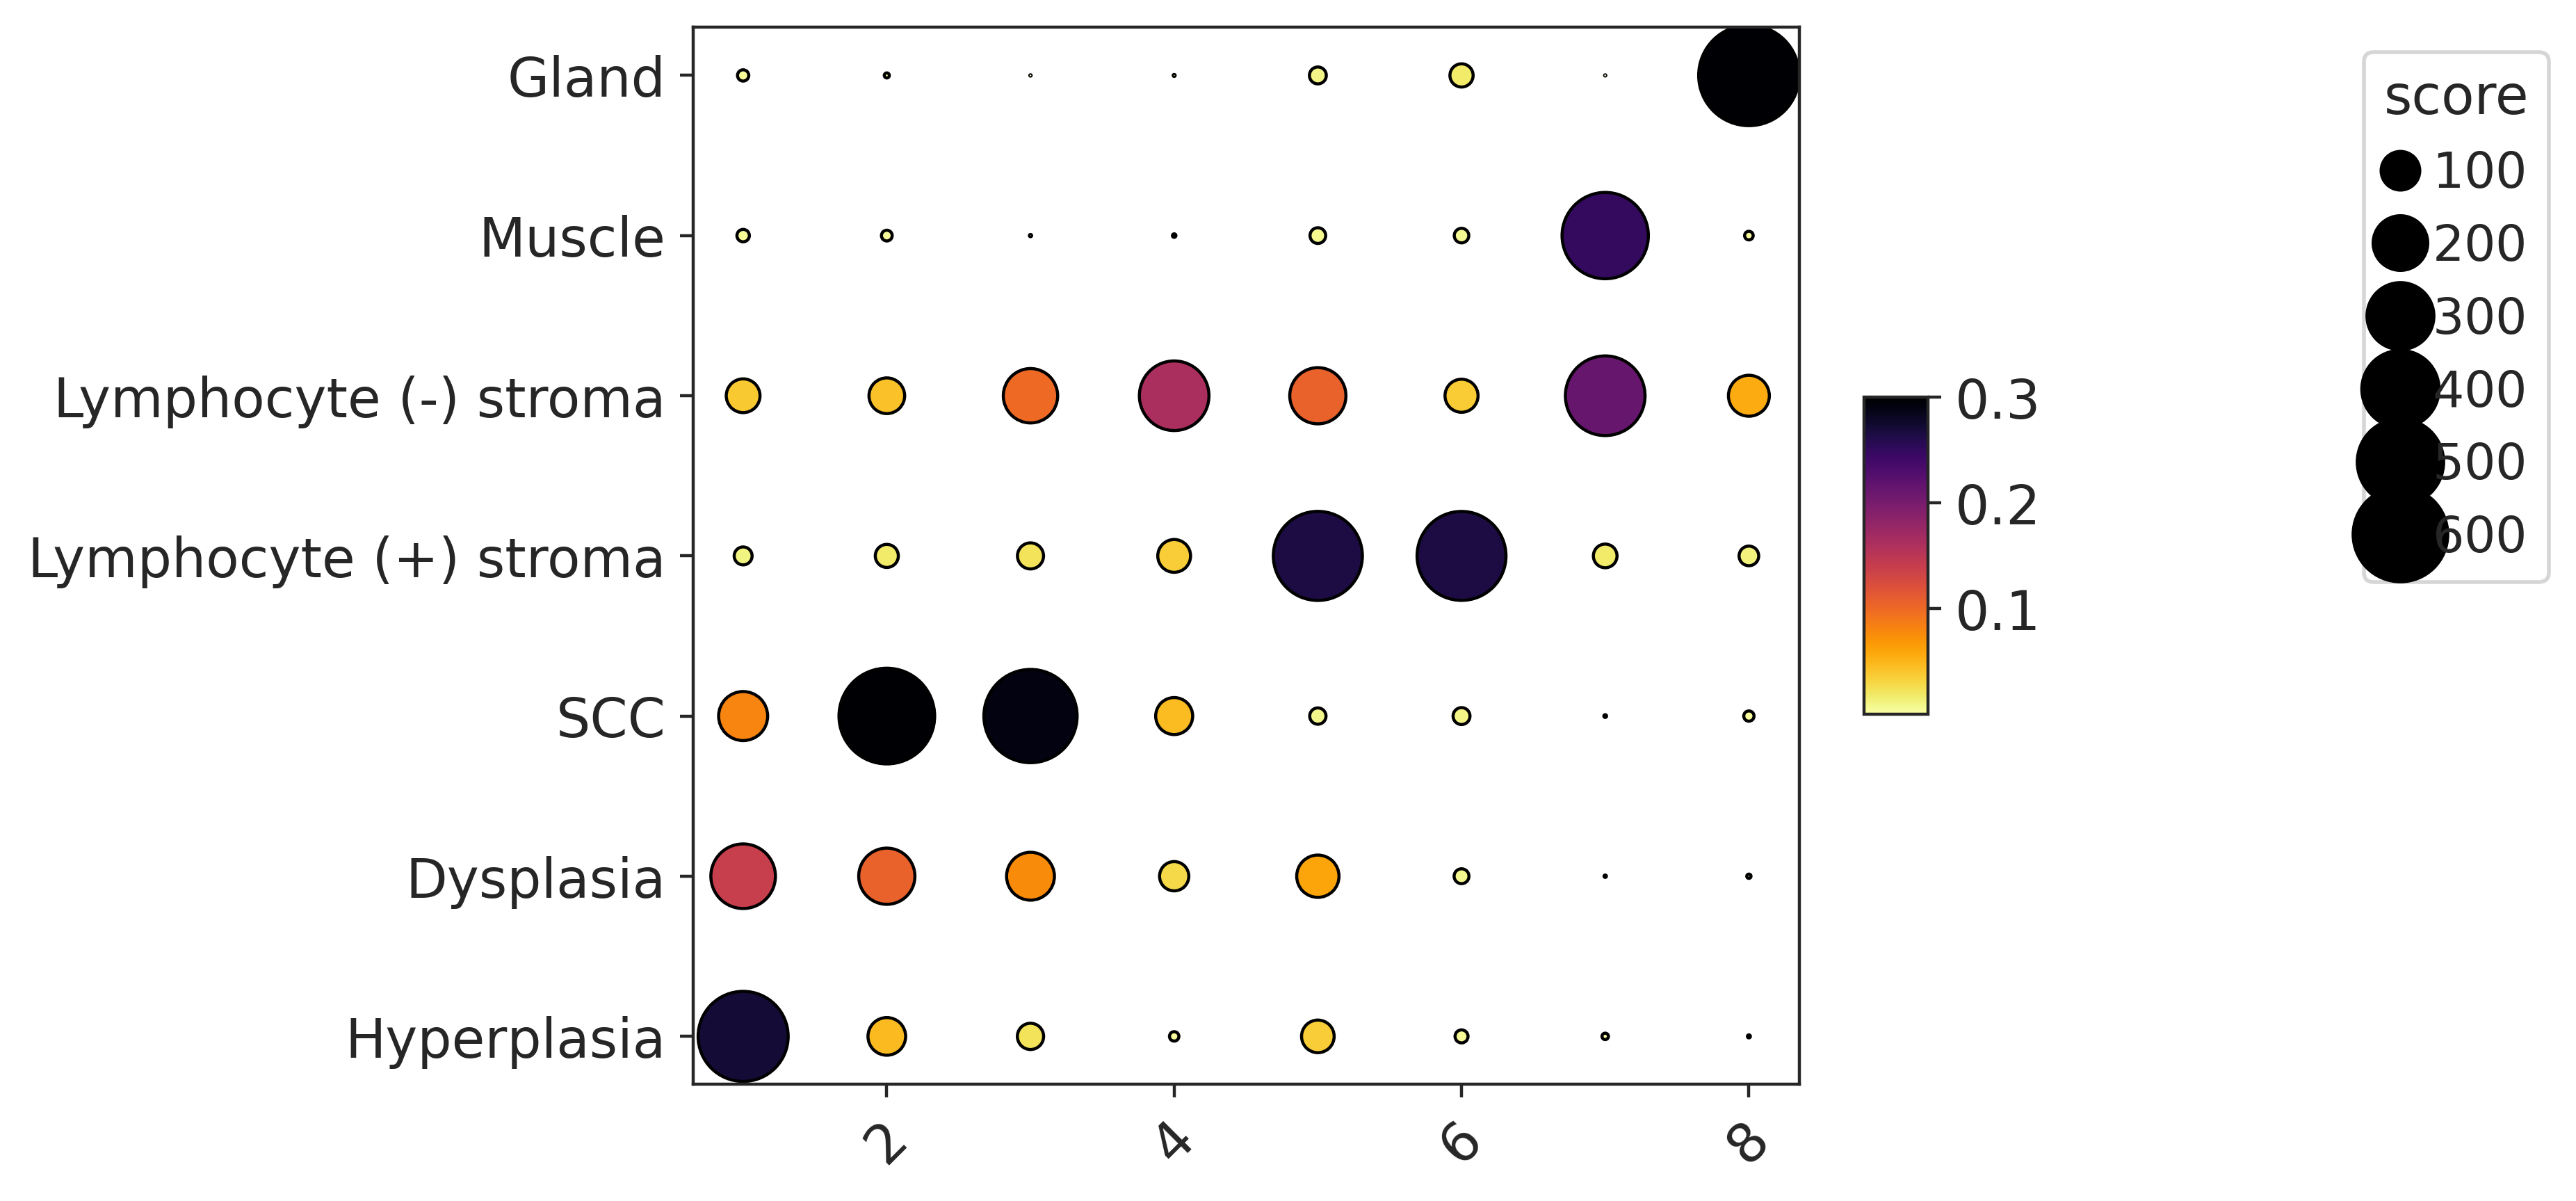

In [99]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(x=jaccard_df['spatial_domain'], y=jaccard_df['patho_anno'], s=jaccard_df['jaccard index']*2000, c=jaccard_df['jaccard index'], cmap='inferno_r',
                      vmax = 0.3,
                      linewidths=0.8, edgecolors='black')

handles, labels = scatter.legend_elements(prop="sizes", num=6)
legend1 = plt.legend(handles, labels, loc="upper right", title="score",frameon=True, bbox_to_anchor=(1.7, 1)) 
_ = plt.colorbar(fraction=0.1, aspect=5, shrink=0.3) 
_ = plt.grid(False)
_ = plt.xticks(rotation=45)
plt.savefig('./Dotplot_patho-anno_and_spatial_domain_composition_relation.pdf', dpi=300)

In [376]:
deconvo = merged_all_ST_analysed.obs.loc[:, 'CCR7+ CD8 Tncm':'Niche']
plot_df = deconvo.groupby(['spatial_domain']).mean()
plot_df.index.name = None

In [49]:
col_order = [
'SBSN+ Epi','GPX2+ Epi','COL17A1+ Epi','MKI67+ Epi','Myofibroblast','INSR+ Endo','Pericyte','C1QA+ Macro','cDC1','Treg','CD14+ Mono','TCF7+ CD4 Tncm','GZMK+ CD8 Teff','CXCL13+ Th1-like',
 'PRF1+ CD8 CTL','CXCR4+ CD4 Trm','FCGR3A+ NK','CRABP1+ Fibro','CCR7+ CD8 Tncm','CD27+ Memory B','CTLA4+ CD8 Tex','ANKRD36+ CD4 Tm','gdT','NR4A2+ CD8 Tem','XCL1+ NK',
 'IGHM+ Naive B', 'IgG PC', 'ACKR1+ Endo', 'Myoblast', 'SMC', 'CFD+ Fibro', 'CA4+ Endo', 'SEMA3G+ Endo', 'IgA PC', 'pDC', 'IL1B+ Macro', 'SG Epithelium'
  ]

In [51]:
dot_df = plot_df.loc[:, col_order]
dot_df['spatial_domain'] = dot_df.index.values
dot_df = dot_df.melt(
    id_vars='spatial_domain',
    value_vars=col_order,
    var_name='refined_celltype',
    value_name = 'Proportion'
)
dot_df['refined_celltype'] = dot_df['refined_celltype'].astype('category')
dot_df['refined_celltype'] = dot_df['refined_celltype'].cat.reorder_categories(col_order)

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def dotplot_seaborn(
    df, x='refined_celltype', y='spatial_domain', value='Proportion',
    cmap='YlGnBu', vmin=-2, vmax=2, sizes=(30, 300),
    figsize=(16, 4),
    min_value=None,        
    min_quantile=None       
):

    mat = df.pivot(index=y, columns=x, values=value)
    col_mean = mat.mean(axis=0)
    col_std  = mat.std(axis=0, ddof=0).replace(0, np.nan)
    mat_z = (mat - col_mean) / col_std

    plot_df = (
        mat.stack().rename('val').reset_index()
        .merge(mat_z.stack().rename('z').reset_index(), on=[y, x])
        .dropna(subset=['val', 'z'])
    )

    
    if min_value is not None:
        plot_df = plot_df[plot_df['val'] >= float(min_value)].copy()
    if min_quantile is not None:
        thr = plot_df['val'].quantile(float(min_quantile))
        plot_df = plot_df[plot_df['val'] >= thr].copy()

   
    vlo, vhi = plot_df['val'].quantile([0.01, 0.99])
    size_norm = mcolors.Normalize(vmin=vlo, vmax=vhi)


    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = sns.color_palette(cmap, as_cmap=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=plot_df, x=x, y=y,
        hue='z', palette=cmap_obj, hue_norm=norm,
        size='val', sizes=sizes, size_norm=size_norm,
        edgecolor='none', legend=False, ax=ax
    )


    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_obj); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.012); cbar.set_label('Proportion z-score')


    fig.subplots_adjust(right=0.82)


    ticks = np.linspace(vlo, vhi, 4)
    handles = [plt.scatter([], [], s=np.interp(t, [vlo, vhi], sizes),
                           facecolor='gray', edgecolor='none') for t in ticks]
    labels = [f"{t:.2g}" for t in ticks]
    fig.legend(handles, labels, title=value,
               loc='upper left', bbox_to_anchor=(0.9, 1.0),
               frameon=True)

    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
    ax.grid(which='both', linestyle=':', alpha=0.3)
    plt.tight_layout()
    return fig, ax


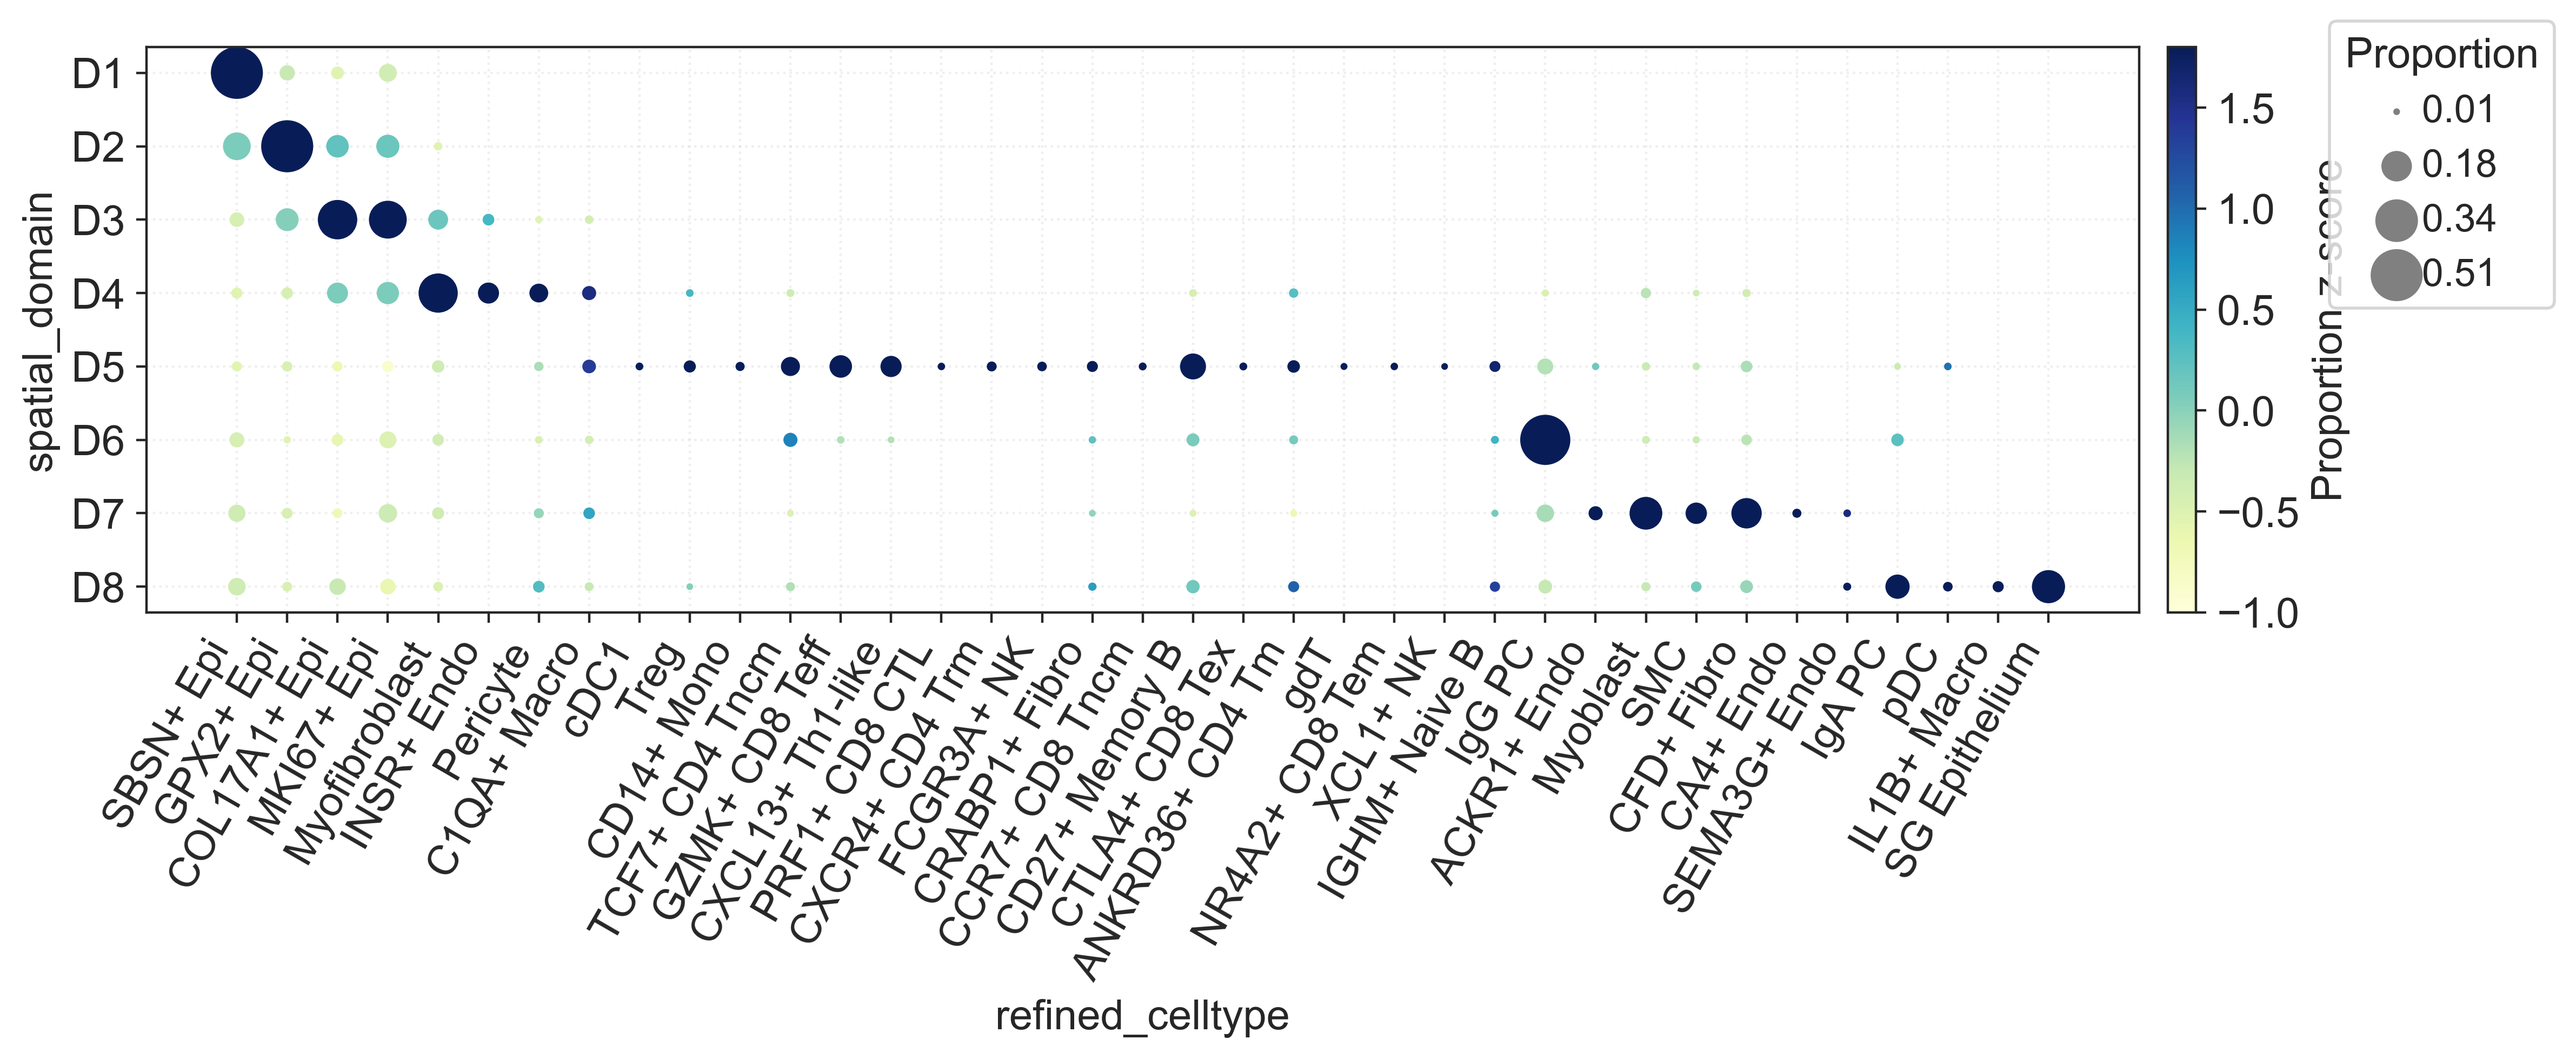

In [53]:
fig, ax = dotplot_seaborn(
    dot_df,
    x='refined_celltype', y='spatial_domain', value='Proportion',
    cmap='YlGnBu', vmin=-1, vmax=1.8, sizes=(5, 300), min_value=0.01,  
    figsize=(12, 5)
)